<a href="https://colab.research.google.com/github/khu3086/NeuralFieldsImplementation/blob/main/SirenImplementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# SIREN Implementation

Sinusoidal Representation Networks

**SIREN** uses **sine activations** instead of ReLU, making neural networks naturally suited for representing signals and their derivatives.

This notebook demonstrates SIREN fitting:
1. **An image** (pixel regression)
2. **A 1D signal** (sine wave fitting)

Reference: [Implicit Neural Representations with Periodic Activation Functions](https://arxiv.org/abs/2006.09661) (Sitzmann et al., 2020)

## Install and Imports

In [10]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import math

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## SIREN Architecture

In [11]:
class SineLayer(nn.Module):
    """
    A single SIREN layer: Linear + sine activation.

    - is_first: True for the input layer (uses different init scale)
    - omega_0: frequency multiplier (default 30 as per paper)
    """
    def __init__(self, in_features, out_features, bias=True, is_first=False, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.is_first = is_first
        self.linear = nn.Linear(in_features, out_features, bias=bias)
        self._init_weights()

    def _init_weights(self):
        with torch.no_grad():
            if self.is_first:
                # Input layer: uniform in [-1/in, 1/in]
                self.linear.weight.uniform_(-1 / self.linear.in_features,
                                             1 / self.linear.in_features)
            else:
                # Hidden layers: uniform in [-sqrt(6/in)/omega_0, sqrt(6/in)/omega_0]
                bound = math.sqrt(6 / self.linear.in_features) / self.omega_0
                self.linear.weight.uniform_(-bound, bound)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class Siren(nn.Module):
    """
    Full SIREN network.

    Args:
        in_features:    input dimensionality (e.g. 2 for image coords)
        hidden_features: width of hidden layers
        hidden_layers:  number of hidden SineLayers
        out_features:   output dimensionality (e.g. 1 for grayscale, 3 for RGB)
        omega_0:        frequency for hidden layers
        first_omega_0:  frequency for the first layer
    """
    def __init__(self, in_features, hidden_features, hidden_layers,
                 out_features, omega_0=30.0, first_omega_0=30.0):
        super().__init__()
        layers = [SineLayer(in_features, hidden_features, is_first=True, omega_0=first_omega_0)]
        for _ in range(hidden_layers):
            layers.append(SineLayer(hidden_features, hidden_features, omega_0=omega_0))
        # Final linear layer (no sine activation)
        final = nn.Linear(hidden_features, out_features)
        with torch.no_grad():
            bound = math.sqrt(6 / hidden_features) / omega_0
            final.weight.uniform_(-bound, bound)
        layers.append(final)
        self.net = nn.Sequential(*layers)

    def forward(self, coords):
        return self.net(coords)

print('✅ SIREN architecture defined!')

✅ SIREN architecture defined!


## Demo- Fit a 1D Signal

In [12]:
# --- Build the target signal ---
x = torch.linspace(-1, 1, 1000).unsqueeze(1)  # (1000, 1)
y = torch.sin(10 * x) + 0.5 * torch.sin(25 * x) + 0.2 * torch.cos(50 * x)  # complex signal

x, y = x.to(device), y.to(device)

# --- SIREN model ---
siren_1d = Siren(in_features=1, hidden_features=64, hidden_layers=3,
                 out_features=1, omega_0=30.0).to(device)

# --- ReLU baseline ---
relu_net = nn.Sequential(
    nn.Linear(1, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 64), nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

def train_model(model, x, y, steps=2000, lr=1e-4):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    losses = []
    for step in range(steps):
        pred = model(x)
        loss = ((pred - y) ** 2).mean()
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if step % 100 == 0:
            losses.append(loss.item())
    return losses

print('Training SIREN...')
siren_losses = train_model(siren_1d, x, y, steps=2000)
print('Training ReLU net...')
relu_losses = train_model(relu_net, x, y, steps=2000)
print('Done!')

Training SIREN...
Training ReLU net...
Done!


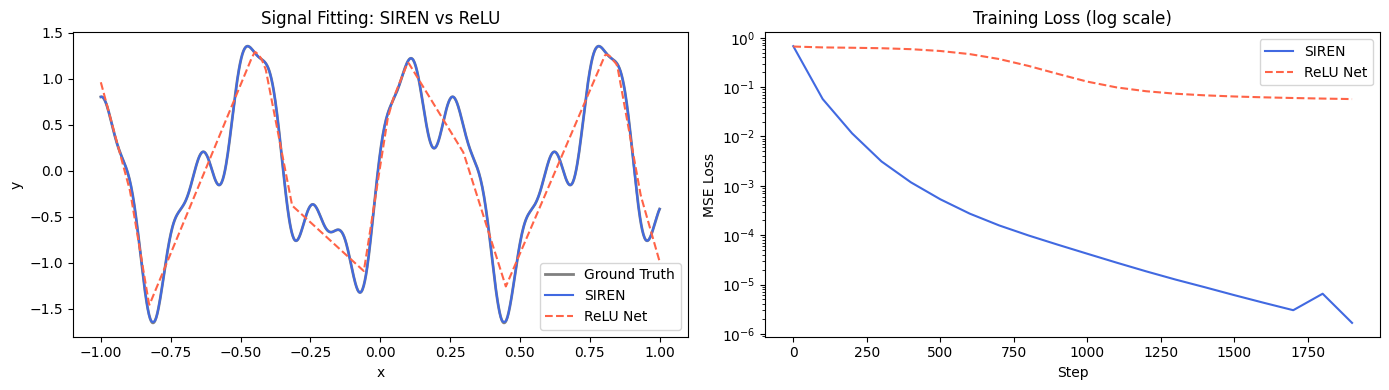

In [13]:
x_cpu = x.cpu()
y_cpu = y.cpu().detach().numpy()

with torch.no_grad():
    siren_pred = siren_1d(x).cpu().numpy()
    relu_pred  = relu_net(x).cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(x_cpu, y_cpu, label='Ground Truth', color='gray', linewidth=2)
axes[0].plot(x_cpu, siren_pred, label='SIREN', color='royalblue', linewidth=1.5)
axes[0].plot(x_cpu, relu_pred, label='ReLU Net', color='tomato', linewidth=1.5, linestyle='--')
axes[0].legend()
axes[0].set_title('Signal Fitting: SIREN vs ReLU')
axes[0].set_xlabel('x')
axes[0].set_ylabel('y')

steps_axis = [i * 100 for i in range(len(siren_losses))]
axes[1].plot(steps_axis, siren_losses, label='SIREN', color='royalblue')
axes[1].plot(steps_axis, relu_losses, label='ReLU Net', color='tomato', linestyle='--')
axes[1].set_yscale('log')
axes[1].legend()
axes[1].set_title('Training Loss (log scale)')
axes[1].set_xlabel('Step')
axes[1].set_ylabel('MSE Loss')

plt.tight_layout()
plt.show()

## Image Fitting Demo

Image shape: 128x128x3


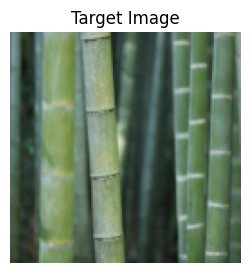

In [19]:
# Load a sample image
IMG_URL = 'https://picsum.photos/seed/siren_image_demo/640/480' # Updated to a reliable public image URL

response = requests.get(IMG_URL)

# --- Added error checking ---
if response.status_code != 200:
    raise requests.exceptions.RequestException(f"Failed to download image. Status code: {response.status_code}")
if 'image' not in response.headers.get('Content-Type', ''):
    raise ValueError(f"Content-Type is not an image: {response.headers.get('Content-Type')}")
# --- End of added error checking ---

img = Image.open(BytesIO(response.content)).convert('RGB')
img = img.resize((128, 128))  # smaller = faster training

img_np = np.array(img) / 255.0  # normalize to [0, 1]
H, W, C = img_np.shape
print(f'Image shape: {H}x{W}x{C}')

plt.figure(figsize=(3, 3))
plt.imshow(img_np)
plt.title('Target Image')
plt.axis('off')
plt.show()

In [20]:
# Build pixel coordinate grid in [-1, 1]
ys = torch.linspace(-1, 1, H)
xs = torch.linspace(-1, 1, W)
grid_y, grid_x = torch.meshgrid(ys, xs, indexing='ij')
coords = torch.stack([grid_x, grid_y], dim=-1).reshape(-1, 2)  # (H*W, 2)
pixels = torch.tensor(img_np, dtype=torch.float32).reshape(-1, 3)  # (H*W, 3)

coords, pixels = coords.to(device), pixels.to(device)

# SIREN for image fitting
siren_img = Siren(
    in_features=2,
    hidden_features=256,
    hidden_layers=4,
    out_features=3,
    omega_0=30.0
).to(device)

optimizer = torch.optim.Adam(siren_img.parameters(), lr=1e-4)

STEPS = 2000
log_every = 200
snapshots = {}

print(f'Training SIREN image network for {STEPS} steps...')
for step in range(1, STEPS + 1):
    pred = siren_img(coords)  # (H*W, 3)
    loss = ((pred - pixels) ** 2).mean()
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if step % log_every == 0 or step == 1:
        print(f'  Step {step:4d} | Loss: {loss.item():.6f}')
        with torch.no_grad():
            img_pred = siren_img(coords).clamp(0, 1).reshape(H, W, 3).cpu().numpy()
        snapshots[step] = img_pred

print('Done!')

Training SIREN image network for 2000 steps...
  Step    1 | Loss: 0.181924
  Step  200 | Loss: 0.000153
  Step  400 | Loss: 0.000059
  Step  600 | Loss: 0.000034
  Step  800 | Loss: 0.000023
  Step 1000 | Loss: 0.000030
  Step 1200 | Loss: 0.000012
  Step 1400 | Loss: 0.000035
  Step 1600 | Loss: 0.000009
  Step 1800 | Loss: 0.000006
  Step 2000 | Loss: 0.000011
Done!


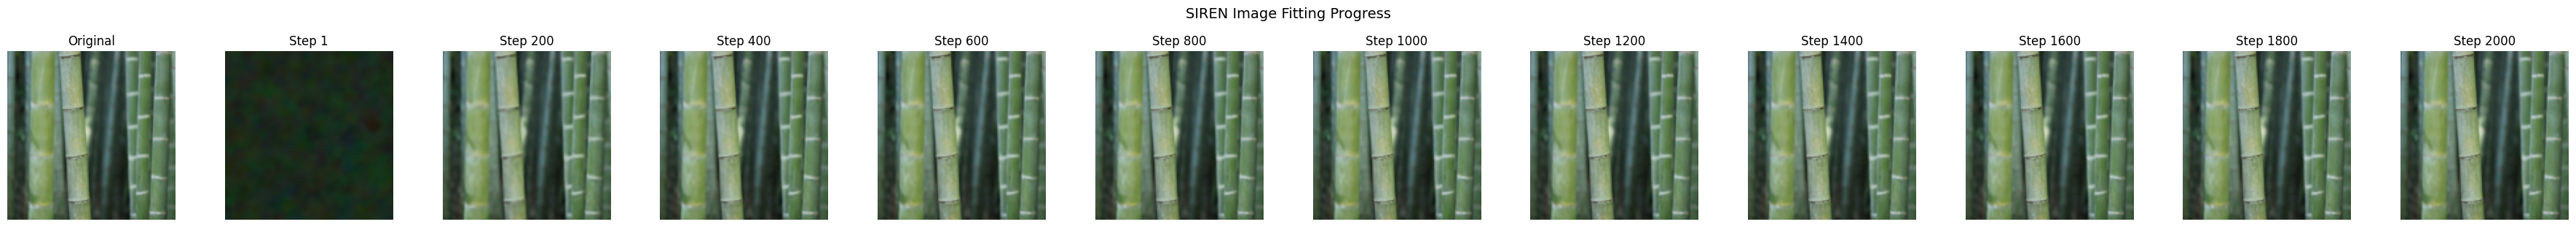

In [21]:
# Plot snapshots
keys = sorted(snapshots.keys())
n = len(keys) + 1
fig, axes = plt.subplots(1, n, figsize=(3 * n, 3))

axes[0].imshow(img_np)
axes[0].set_title('Original')
axes[0].axis('off')

for ax, step in zip(axes[1:], keys):
    ax.imshow(snapshots[step])
    ax.set_title(f'Step {step}')
    ax.axis('off')

plt.suptitle('SIREN Image Fitting Progress', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## SIREN Learning Derivatives Demo

Temporarily training SIREN for image within this cell for demonstration purposes...
Finished temporary image SIREN training.


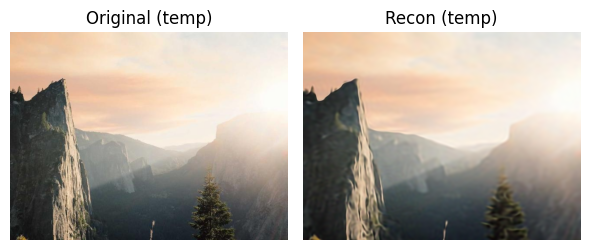

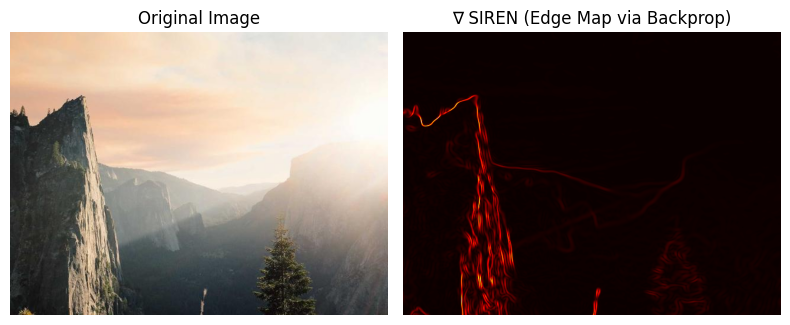

Edges extracted directly from SIREN gradient — no CV library needed!


In [24]:
# --- Added code to set up image regression for the derivative demo ---
# This part was missing and caused NameErrors for 'coords', 'siren_img', 'H', 'W', 'img_np'.

# Load and preprocess image
image_url = "https://picsum.photos/seed/siren_derivative_demo/640/480" # Updated to a reliable public image URL
response = requests.get(image_url)

# --- Added error checking ---
if response.status_code != 200:
    raise requests.exceptions.RequestException(f"Failed to download image. Status code: {response.status_code}")
if 'image' not in response.headers.get('Content-Type', ''):
    raise ValueError(f"Content-Type is not an image: {response.headers.get('Content-Type')}")
# --- End of added error checking ---

img = Image.open(BytesIO(response.content)).convert('RGB')
img_np = np.array(img).astype(np.float32) / 255.0 # Normalize to [0, 1]
H, W, C = img_np.shape

# Prepare coordinates
# Generate pixel coordinates (normalized to [-1, 1])
x_coords = torch.linspace(-1, 1, W)
y_coords = torch.linspace(-1, 1, H)
coords = torch.stack(torch.meshgrid(y_coords, x_coords, indexing='ij'), -1).reshape(-1, 2)
img_tensor = torch.from_numpy(img_np).reshape(-1, C)

coords, img_tensor = coords.to(device), img_tensor.to(device)

# SIREN model for image
siren_img = Siren(in_features=2, hidden_features=256, hidden_layers=4,
                 out_features=C, omega_0=30.0).to(device)

# A simple training loop for the image SIREN to ensure it has learned something
# This uses the train_model function defined earlier for 1D signal.
# In a real scenario, this would ideally be in a separate training cell.
print('Temporarily training SIREN for image within this cell for demonstration purposes...')
# Using a smaller number of steps here to keep execution time reasonable for a fix,
# but usually image fitting requires more steps (e.g., 4000-8000+).
_ = train_model(siren_img, coords, img_tensor, steps=1000, lr=1e-4)
print('Finished temporary image SIREN training.')

# Optionally, display reconstructed image to ensure training was somewhat successful
with torch.no_grad():
    recon_img_tensor = siren_img(coords).cpu().numpy()
recon_img_np = recon_img_tensor.reshape(H, W, C)
plt.figure(figsize=(6, 3))
plt.subplot(1, 2, 1)
plt.imshow(img_np)
plt.title('Original (temp)')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(np.clip(recon_img_np, 0, 1))
plt.title('Recon (temp)')
plt.axis('off')
plt.tight_layout()
plt.show()
# --- End of added setup code ---

coords_grad = coords.clone().requires_grad_(True)
pred = siren_img(coords_grad)

# Sum over channels and compute gradient w.r.t. input coords
pred.sum().backward()
grads = coords_grad.grad.detach().cpu()  # (H*W, 2)

grad_magnitude = grads.norm(dim=-1).reshape(H, W).numpy()
grad_magnitude = (grad_magnitude - grad_magnitude.min()) / (grad_magnitude.max() - grad_magnitude.min())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_np)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(grad_magnitude, cmap='hot')
axes[1].set_title('∇ SIREN (Edge Map via Backprop)')
axes[1].axis('off')

plt.tight_layout()
plt.show()
print('Edges extracted directly from SIREN gradient — no CV library needed!')